# 01 - Análisis Exploratorio de Datos (EDA)

## Etapa 1 del Ciclo de Vida MLOps: Comprensión del Dato

En un proyecto MLOps profesional, el EDA no es un paso opcional: es la base sobre la que se toman todas las decisiones posteriores. Antes de entrenar cualquier modelo, debemos entender profundamente los datos con los que trabajamos.

**¿Qué responderemos en este notebook?**
- ¿Cómo se distribuye la variable objetivo?
- ¿Hay valores nulos o anomalías?
- ¿Qué features tienen mayor correlación con el precio?
- ¿Existen patrones geográficos en los datos?

**Dataset**: California Housing (scikit-learn) — precios medianos de viviendas en distritos de California (1990).

**Variable objetivo**: `MedHouseVal` — valor mediano de la vivienda en cientos de miles de dólares.

## Prerequisitos
- Sin prerequisitos — este es el punto de partida
- Este notebook genera: `data/raw/housing_raw.csv`

## 1. Imports y Configuración

Importamos las librerías estándar de análisis de datos. En MLOps es buena práctica fijar seeds y configurar el estilo de visualización desde el inicio para garantizar reproducibilidad.

In [1]:
from pathlib import Path
import sys

# Detectar ROOT automáticamente — funciona en cualquier equipo
ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
# Añadir ROOT al path para importar módulos del proyecto
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Configuración de estilo
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

print("Librerías cargadas correctamente.")
print(f"ROOT del proyecto: {ROOT}")

Librerías cargadas correctamente.
ROOT del proyecto: C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida


## 2. Carga de Datos

Cargamos el dataset de California Housing directamente desde scikit-learn. Este dataset contiene información de 20,640 distritos censales de California con 8 features numéricas.

En un entorno MLOps real, los datos vendrían de un data warehouse o feature store, pero el principio es el mismo: trazabilidad y versionado.

In [2]:
# Cargar dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("=== Información del Dataset ===")
print(f"Shape: {df.shape}")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nPrimeras filas:")
df.head()

=== Información del Dataset ===
Shape: (20640, 9)

Columnas: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Primeras filas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Estadísticas descriptivas
print("=== Estadísticas Descriptivas ===")
df.describe().round(3)

=== Estadísticas Descriptivas ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


## 3. Análisis de Calidad de Datos

Antes de cualquier modelado, verificamos la calidad del dato. Los valores nulos, duplicados y tipos incorrectos pueden silenciosamente degradar el rendimiento de un modelo en producción.

**En MLOps**: este análisis alimenta las reglas de validación del pipeline de datos.

In [4]:
# Análisis de valores nulos
print("=== Valores Nulos por Columna ===")
nulos = df.isnull().sum()
print(nulos)
print(f"\nTotal de filas: {len(df)}")
print(f"Total de valores nulos: {nulos.sum()}")

# Verificar duplicados
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

# Tipos de datos
print("\n=== Tipos de Datos ===")
print(df.dtypes)

=== Valores Nulos por Columna ===
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total de filas: 20640
Total de valores nulos: 0
Filas duplicadas: 0

=== Tipos de Datos ===
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


## 4. Distribución de la Variable Objetivo

La variable objetivo `MedHouseVal` representa el valor mediano de la vivienda en cientos de miles de dólares. Entender su distribución nos informa:

- Si necesitamos transformarla (e.g., log-transform para distribuciones sesgadas)
- Si hay valores "capeados" que indiquen truncamiento en los datos
- El rango de predicciones esperado en producción

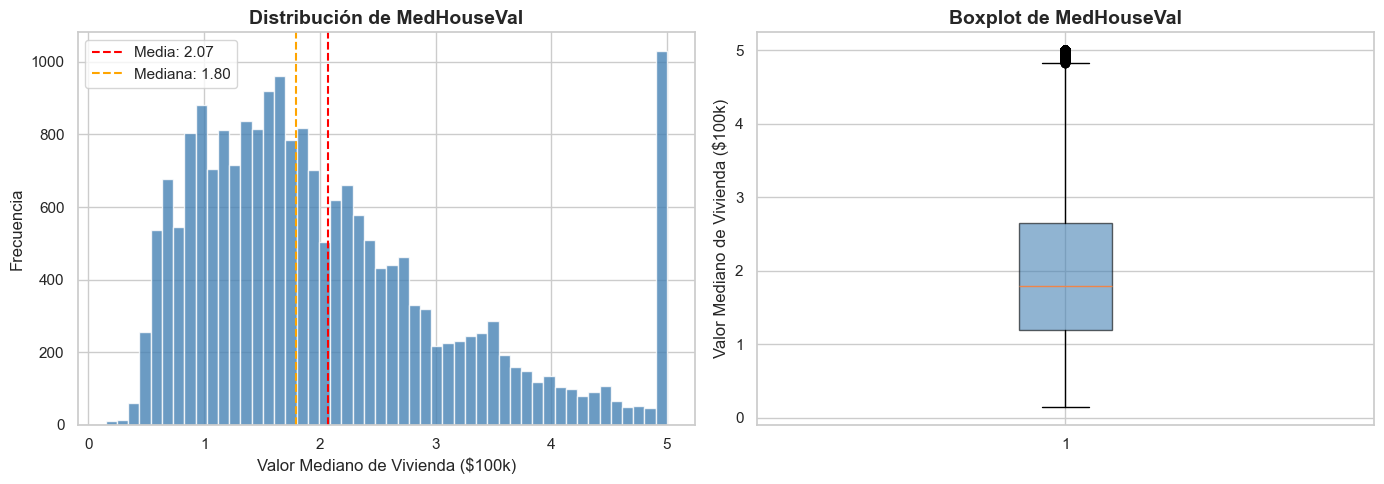

Skewness: 0.978
Kurtosis: 0.328
Nota: Hay un pico en 5.0 — los valores están capeados en $500,000


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución de MedHouseVal', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Valor Mediano de Vivienda ($100k)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['MedHouseVal'].mean(), color='red', linestyle='--', label=f"Media: {df['MedHouseVal'].mean():.2f}")
axes[0].axvline(df['MedHouseVal'].median(), color='orange', linestyle='--', label=f"Mediana: {df['MedHouseVal'].median():.2f}")
axes[0].legend()

# Boxplot
axes[1].boxplot(df['MedHouseVal'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot de MedHouseVal', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Valor Mediano de Vivienda ($100k)')

plt.tight_layout()
plt.show()

print(f"Skewness: {df['MedHouseVal'].skew():.3f}")
print(f"Kurtosis: {df['MedHouseVal'].kurtosis():.3f}")
print(f"Nota: Hay un pico en 5.0 — los valores están capeados en $500,000")

## 5. Distribución de cada Feature

Analizamos la distribución de cada feature para detectar:
- **Sesgo**: features muy asimétricas pueden beneficiarse de transformaciones
- **Outliers**: valores extremos que podrían ser errores o casos especiales
- **Rango**: informa si necesitamos normalización/estandarización

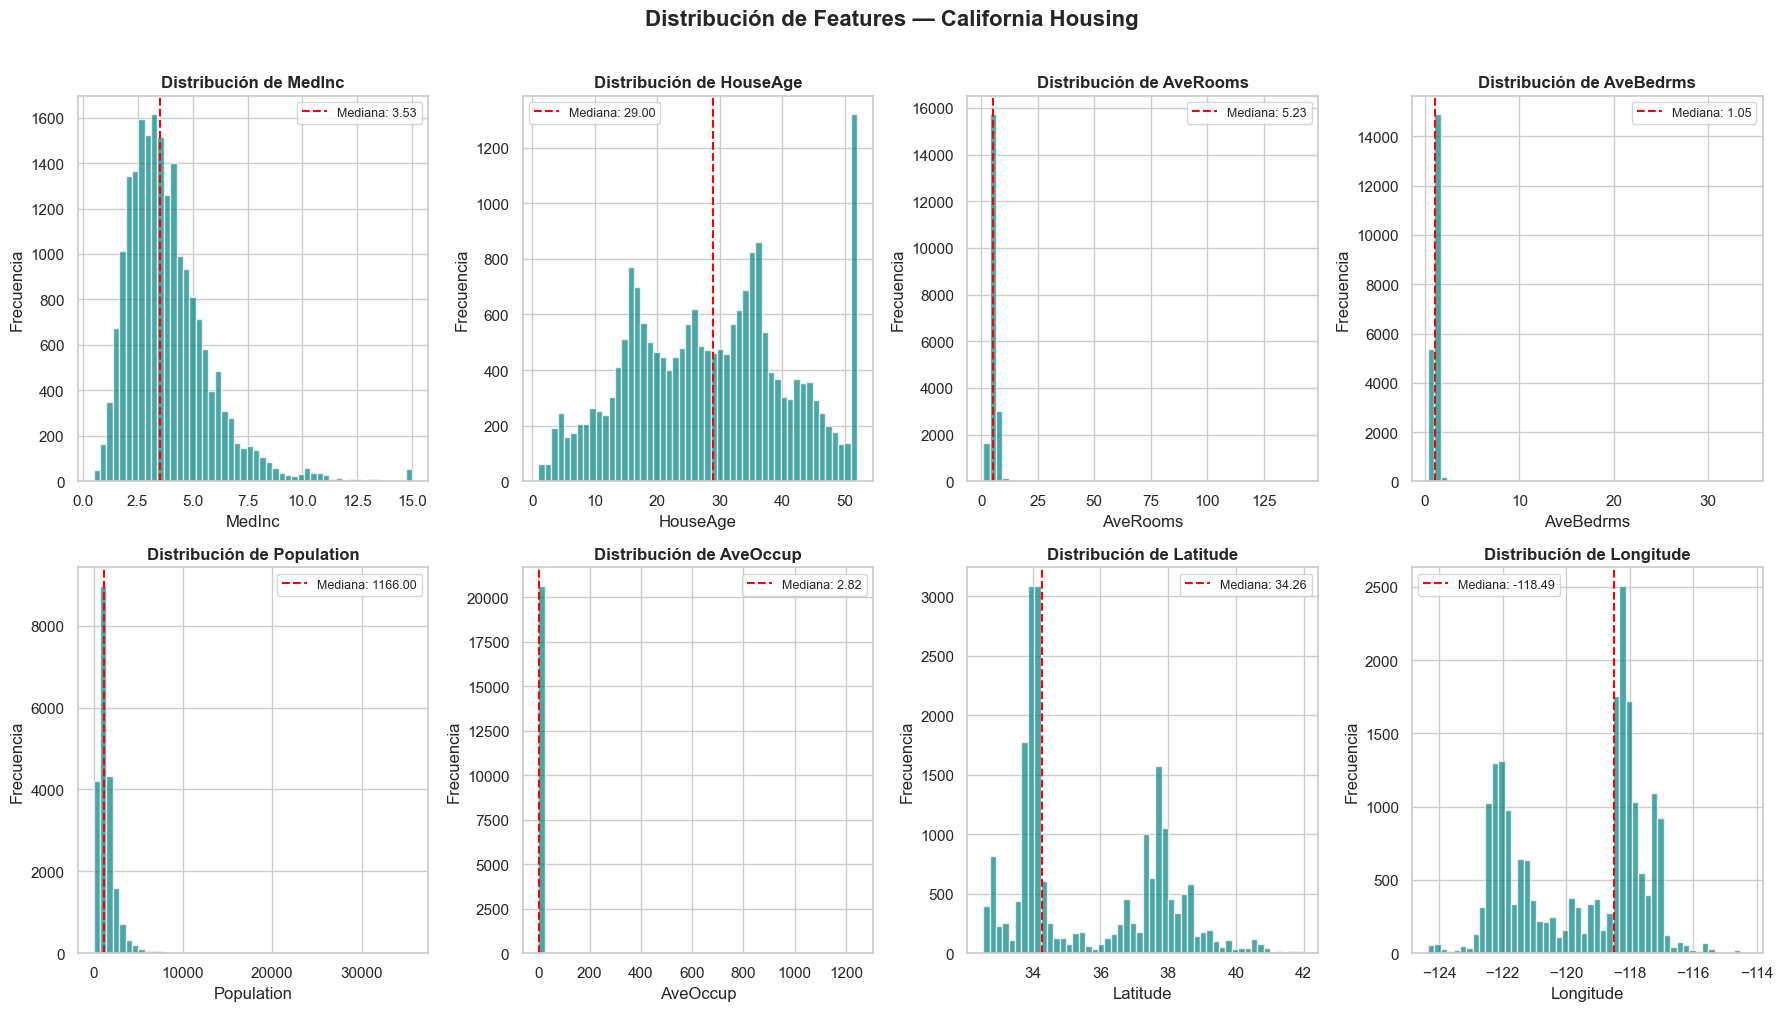

In [6]:
features = [c for c in df.columns if c != 'MedHouseVal']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=50, color='teal', edgecolor='white', alpha=0.7)
    axes[i].set_title(f'Distribución de {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frecuencia')
    axes[i].axvline(df[feature].median(), color='red', linestyle='--', linewidth=1.5,
                    label=f'Mediana: {df[feature].median():.2f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribución de Features — California Housing', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Matriz de Correlación

La matriz de correlación nos permite identificar:
- **Correlación feature-target**: qué variables tienen más poder predictivo
- **Multicolinealidad**: features altamente correlacionadas entre sí (problema para regresión lineal)

En MLOps, este análisis guía la selección de features y la ingeniería de variables derivadas.

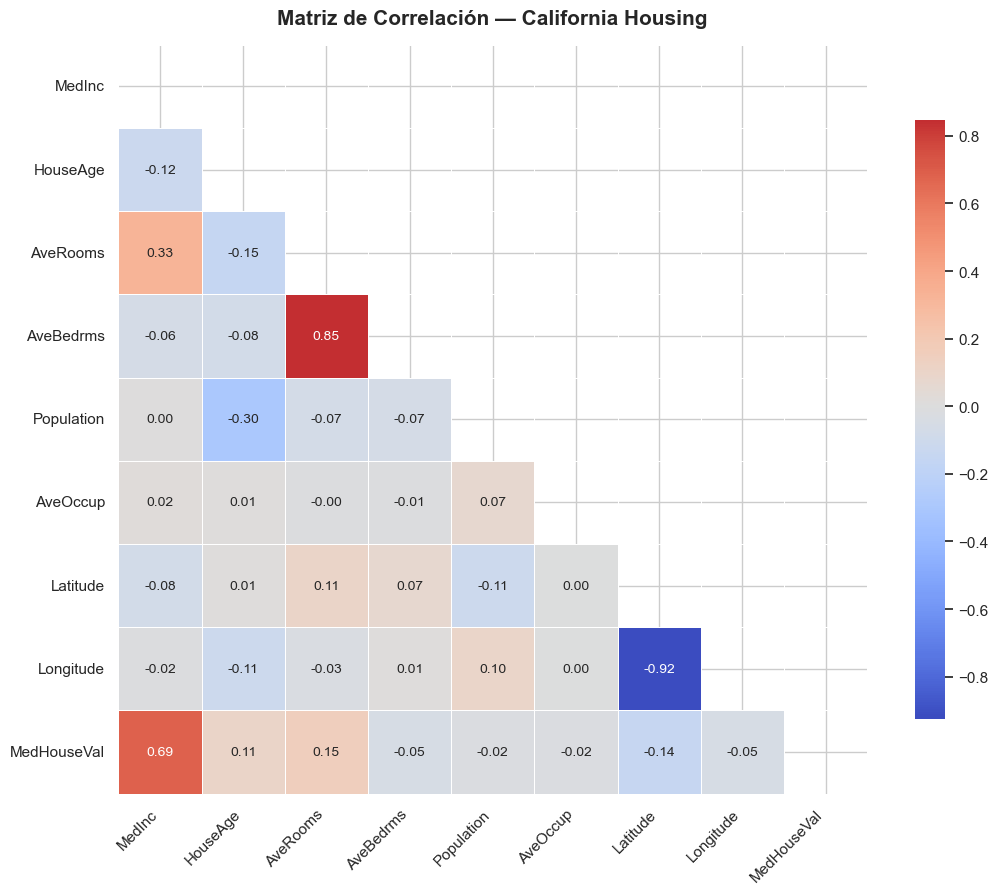

In [7]:
plt.figure(figsize=(11, 9))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 10}
)
plt.title('Matriz de Correlación — California Housing', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Correlación Feature vs Target

Ordenamos las features por su correlación absoluta con `MedHouseVal` para identificar rápidamente cuáles son más informativas para el modelo.

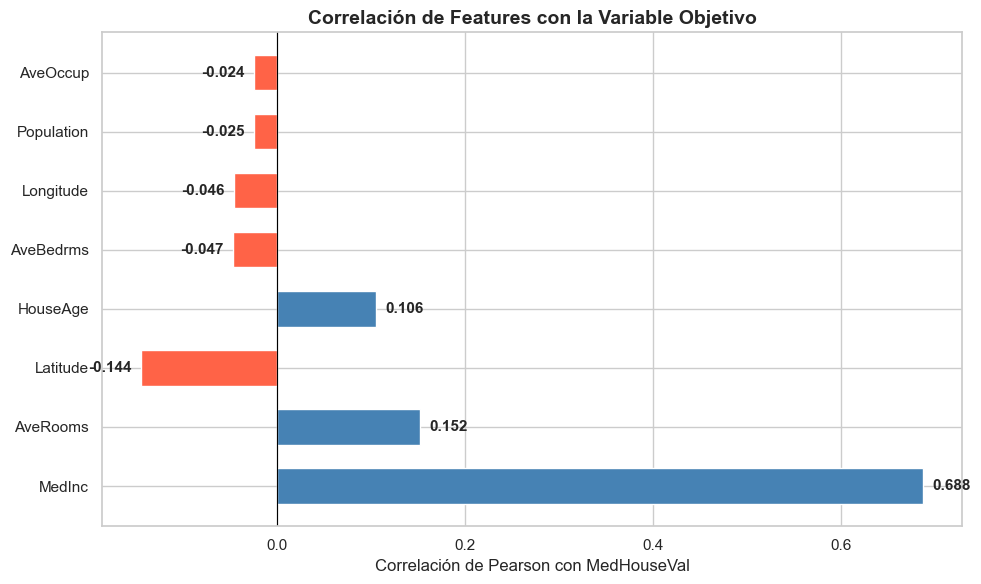

Top features por correlación absoluta:
  MedInc         : +0.688
  AveRooms       : +0.152
  Latitude       : -0.144
  HouseAge       : +0.106
  AveBedrms      : -0.047
  Longitude      : -0.046
  Population     : -0.025
  AveOccup       : -0.024


In [8]:
correlaciones = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['steelblue' if v > 0 else 'tomato' for v in correlaciones.values]
bars = ax.barh(correlaciones.index, correlaciones.values, color=colores, edgecolor='white', height=0.6)

for bar, val in zip(bars, correlaciones.values):
    ax.text(val + 0.01 if val >= 0 else val - 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=11, fontweight='bold')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson con MedHouseVal', fontsize=12)
ax.set_title('Correlación de Features con la Variable Objetivo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top features por correlación absoluta:")
for feat, val in correlaciones.items():
    print(f"  {feat:15s}: {val:+.3f}")

## 8. Scatter Plots de las Features Más Correlacionadas

Visualizamos la relación individual de las 3 features con mayor correlación absoluta contra el target. Esto revela si la relación es lineal, no-lineal o si existen clusters.

Top 3 features más correlacionadas: ['MedInc', 'AveRooms', 'Latitude']


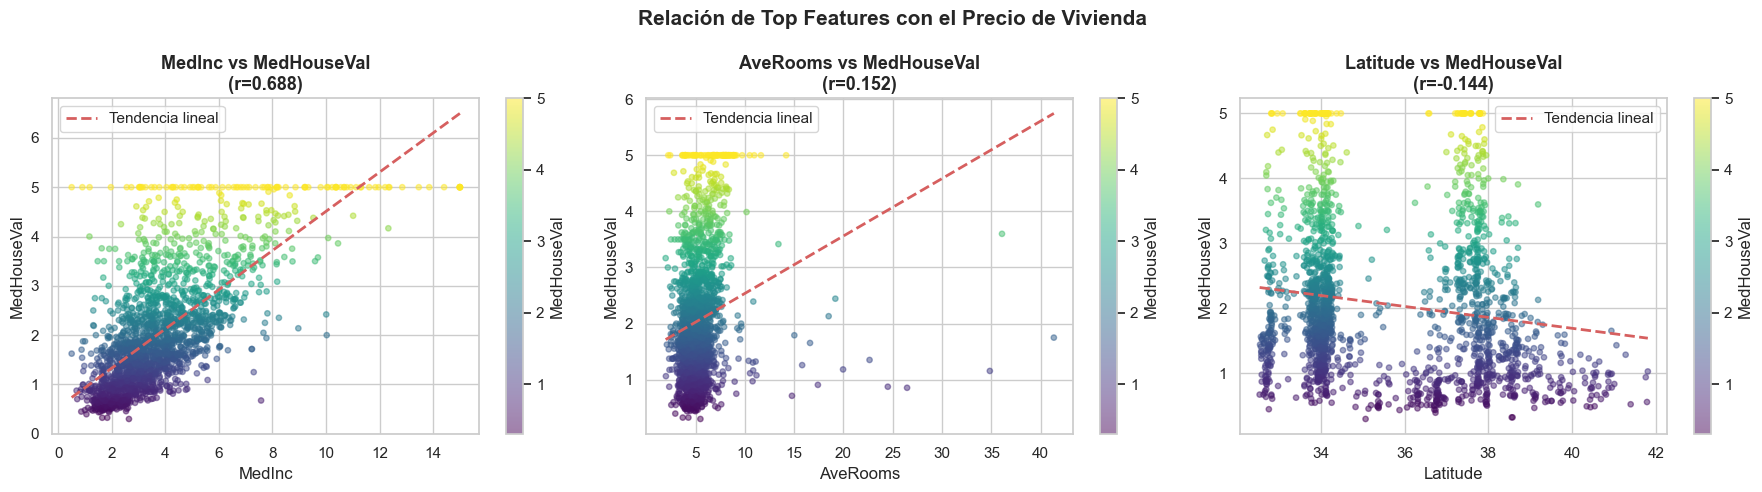

In [9]:
top3 = correlaciones.abs().nlargest(3).index.tolist()
print(f"Top 3 features más correlacionadas: {top3}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(top3):
    # Sample 2000 puntos para visualización más clara
    sample = df.sample(2000, random_state=42)
    scatter = axes[i].scatter(
        sample[feature], sample['MedHouseVal'],
        c=sample['MedHouseVal'], cmap='viridis', alpha=0.5, s=15
    )
    # Línea de tendencia
    z = np.polyfit(sample[feature], sample['MedHouseVal'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample[feature].min(), sample[feature].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Tendencia lineal')
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel('MedHouseVal', fontsize=12)
    axes[i].set_title(f'{feature} vs MedHouseVal\n(r={correlaciones[feature]:.3f})',
                       fontsize=13, fontweight='bold')
    axes[i].legend()
    plt.colorbar(scatter, ax=axes[i], label='MedHouseVal')

plt.suptitle('Relación de Top Features con el Precio de Vivienda', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Visualización Geográfica

California Housing contiene coordenadas geográficas (Latitude, Longitude). Este mapa de calor geográfico revela patrones espaciales en los precios que las features numéricas no capturan directamente.

**Insight clave**: las zonas costeras y áreas metropolitanas (San Francisco, Los Ángeles) muestran precios significativamente más altos. Esto motiva crear features de distancia a estas ciudades en el siguiente notebook.

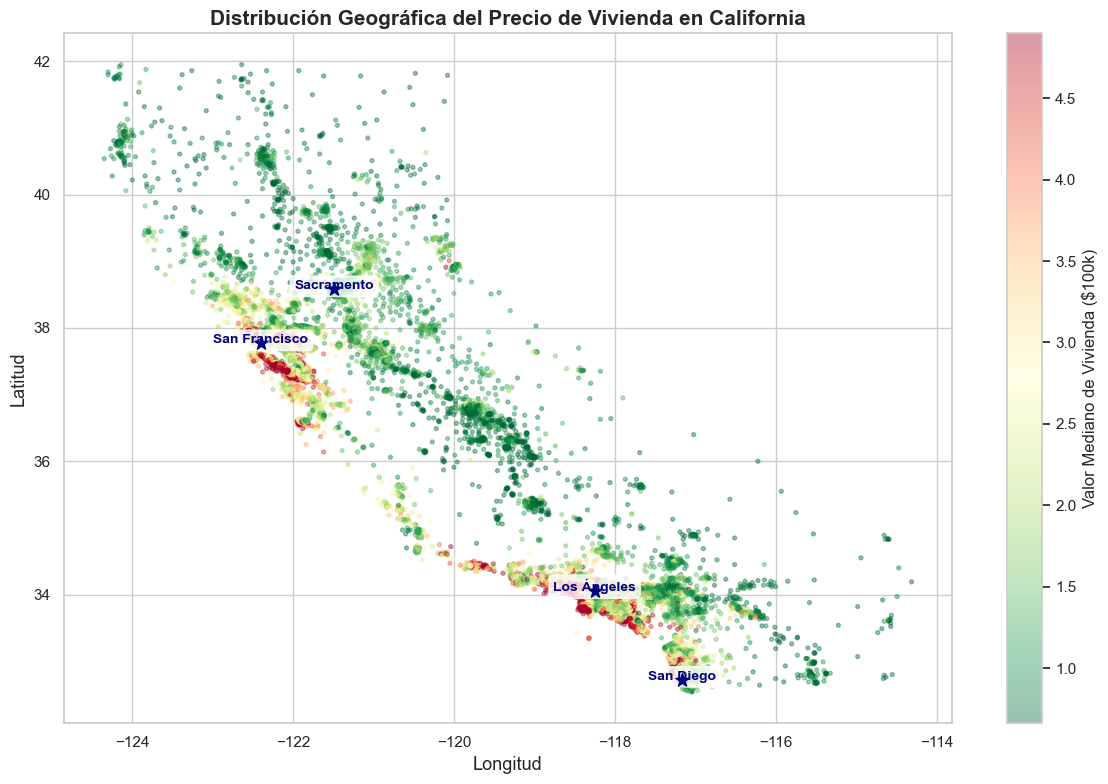

In [10]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df['Longitude'], df['Latitude'],
    c=df['MedHouseVal'], cmap='RdYlGn_r',
    alpha=0.4, s=8,
    vmin=df['MedHouseVal'].quantile(0.05),
    vmax=df['MedHouseVal'].quantile(0.95)
)
plt.colorbar(scatter, label='Valor Mediano de Vivienda ($100k)')
plt.xlabel('Longitud', fontsize=13)
plt.ylabel('Latitud', fontsize=13)
plt.title('Distribución Geográfica del Precio de Vivienda en California', fontsize=15, fontweight='bold')

# Marcar ciudades principales
ciudades = {
    'San Francisco': (-122.4, 37.77),
    'Los Ángeles': (-118.25, 34.05),
    'San Diego': (-117.16, 32.72),
    'Sacramento': (-121.49, 38.58)
}
for ciudad, (lon, lat) in ciudades.items():
    plt.annotate(ciudad, (lon, lat), fontsize=10, fontweight='bold',
                 color='navy', ha='center',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    plt.scatter(lon, lat, s=100, c='navy', zorder=5, marker='*')

plt.tight_layout()
plt.show()

## 10. Análisis de Outliers

Los outliers pueden ser ruido o señal real. Los identificamos con boxplots para decidir si filtrarlos o dejarlos en el dataset.

**En MLOps**: el tratamiento de outliers debe estar codificado en el pipeline de datos y aplicarse de forma consistente en entrenamiento y producción.

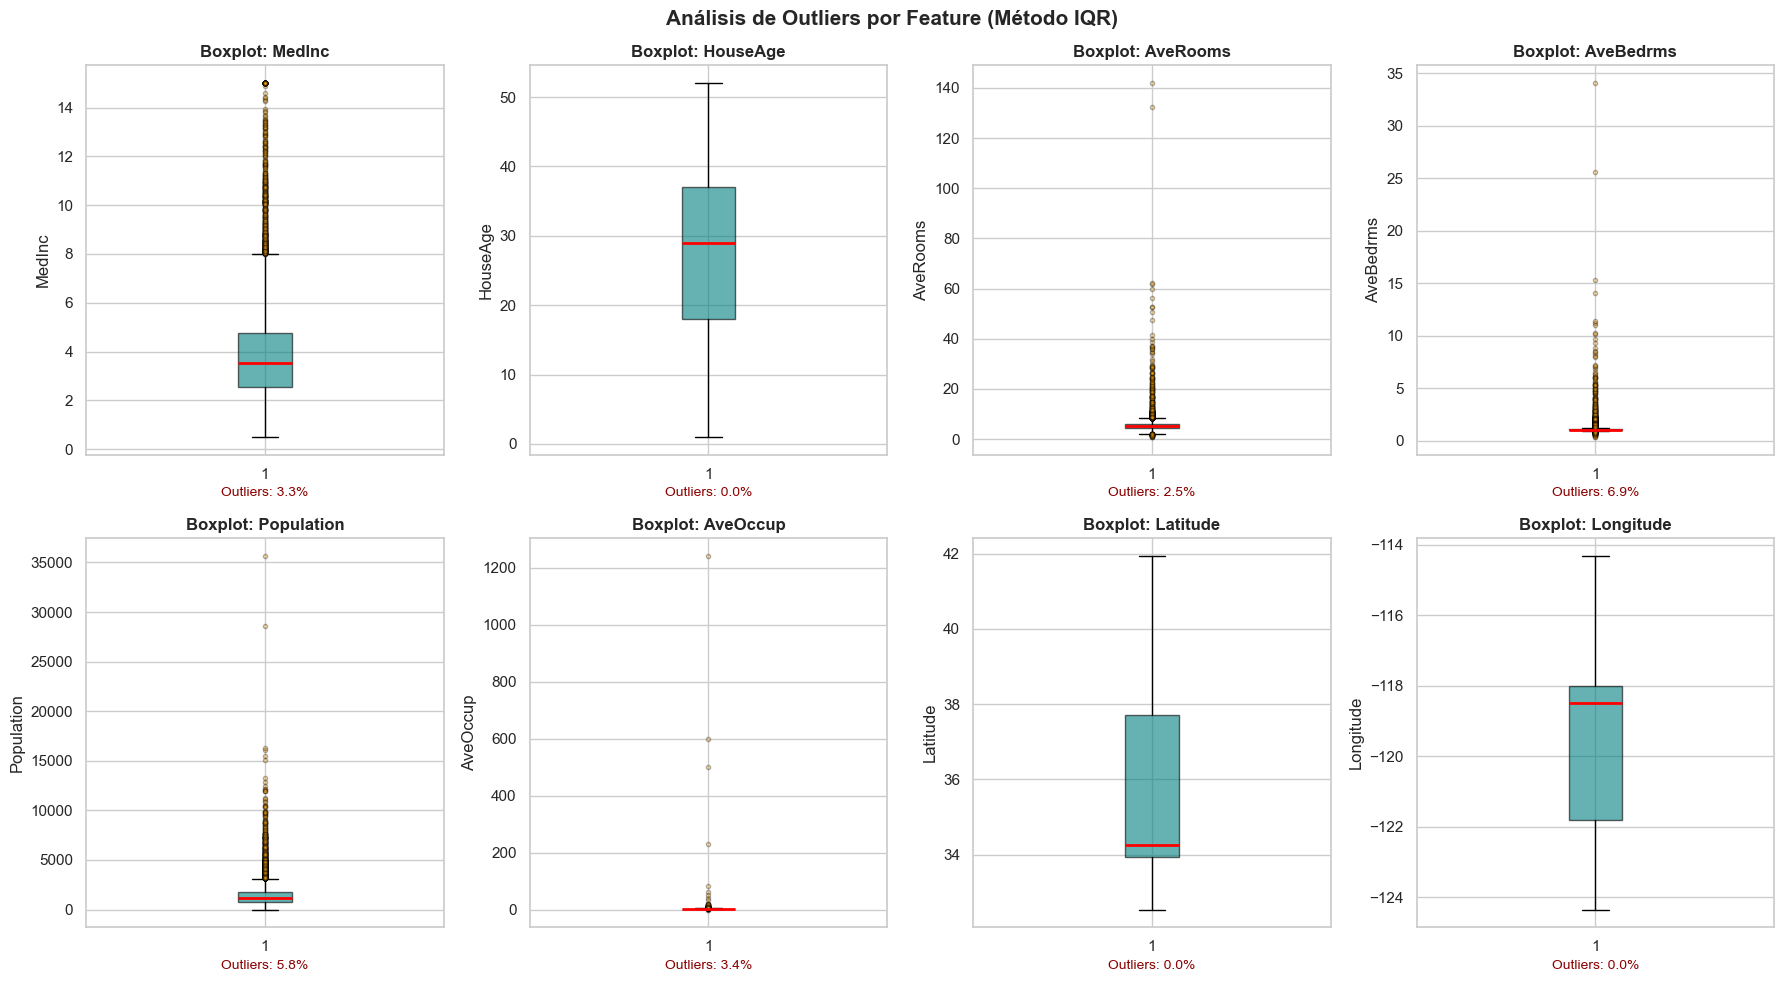

In [11]:
features_plot = [c for c in df.columns if c != 'MedHouseVal']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(features_plot):
    axes[i].boxplot(df[feature], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='teal', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='orange', markersize=3, alpha=0.3))
    axes[i].set_title(f'Boxplot: {feature}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(feature)

    # Calcular % de outliers (IQR method)
    Q1, Q3 = df[feature].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers_pct = ((df[feature] < Q1 - 1.5*IQR) | (df[feature] > Q3 + 1.5*IQR)).mean() * 100
    axes[i].set_xlabel(f'Outliers: {outliers_pct:.1f}%', fontsize=10, color='darkred')

plt.suptitle('Análisis de Outliers por Feature (Método IQR)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Conclusiones del EDA

### Lo que aprendimos:

1. **Calidad del dato**: No hay valores nulos ni duplicados. El dataset es limpio y listo para modelado.

2. **Variable objetivo sesgada**: `MedHouseVal` tiene un pico artificial en 5.0 ($500k) porque los valores están capeados. Esto puede afectar la precisión del modelo en ese rango.

3. **Features más importantes**:
   - `MedInc` (ingresos medianos) tiene la correlación más alta con el precio (~0.69)
   - `Latitude` y `Longitude` muestran patrones geográficos claros
   - `AveRooms` y `HouseAge` tienen correlación moderada

4. **Multicolinealidad**: `AveRooms` y `AveBedrms` están altamente correlacionadas entre sí.

5. **Patrones geográficos**: San Francisco y Los Ángeles tienen los precios más altos. Esto motiva crear features de distancia a estas ciudades.

6. **Outliers**: `AveRooms`, `AveBedrms` y `Population` tienen outliers extremos que deberían considerarse.

### Guía para el siguiente paso:
- Crear features derivadas (distancia a ciudades, ratios entre features)
- Aplicar StandardScaler para normalizar las distribuciones
- El modelo de ensemble probablemente supere a la regresión lineal dado el patrón no-lineal de varias features

**Siguiente notebook**: `02_ingenieria_features.ipynb`

In [12]:
# Guardar datos crudos para el siguiente notebook
import pandas as pd
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df_raw = housing.frame.copy()
# Mantenemos el nombre original 'MedHouseVal' para compatibilidad con el resto del pipeline

ruta_raw = ROOT / "data" / "raw" / "housing_raw.csv"
ruta_raw.parent.mkdir(parents=True, exist_ok=True)
df_raw.to_csv(ruta_raw, index=False)
print(f"Datos guardados en: {ruta_raw}")
print(f"   Shape: {df_raw.shape}")
print(f"   Columnas: {list(df_raw.columns)}")
print(f"\nSiguiente paso: ejecutar 02_ingenieria_features.ipynb")

Datos guardados en: C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\data\raw\housing_raw.csv
   Shape: (20640, 9)
   Columnas: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Siguiente paso: ejecutar 02_ingenieria_features.ipynb
